# 1. Data Preperation
## 1.1 Load Modules

In [30]:
import gdown
import os

import xarray as xr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from IPython.display import HTML

import cmcrameri.cm as cmc
import hvplot.xarray

## 1.2 Download data

the data was downloaded yousing the following *Google Earth Engine* script: https://code.earthengine.google.com/04afb4de7a1d95d988d2972e3ed87ffd.
--> downloads image from July 1st of the START year of each 3-year block

Band positions: *1. Blue, 2. Green , 3. Red, 4. NIR, 5. SWIR1, 6. SWIR2, 7. TIR1*

### Automatic download from Google Drive:

In [ ]:
# Create data directory
data_folder = "../data"
os.makedirs(data_folder, exist_ok=True)

# Dictionary of file IDs and their output names
datasets = {
    1985: "1TOFy-yTz5KNsVAH-dh0YejLSb8pAqFas",
    1988:"1lYyrBD97drS3H_pxI0nLmXpU4S9Zw8b1",
    1991:"1JxT2CNw6y1RTHXwFJ0nm-_4unLJxBRUJ",
    1994:"1TOFy-yTz5KNsVAH-dh0YejLSb8pAqFas",
    1997:"1ysdgB8XYwEEYXl578CMQzVK8ZZ2XHTku",
    2000:"1s7Nnl80wGbMh1xyEV7Dx9YqaZPNpOZb_",
    2003:"11ES9OyhetkfvH8DTOi5BCJdoWVLCCQX7",
    2006:"1S-LoLT967qDS8d1bp_wXaRnja0JscuJu",
    2009:"1doUkH38hT1tle41qeQ7AH8aDjGIQ0F90",
    2012:"1o4sFKySMZl1e2W9cGU3EyB4KCO9CvJZh",
    2015:"1XwhUhv3FW4sFx3ubGf9v-dyq9I-Idq_b",
    2018:"1t16HUGh17ldTojX3lrt3MMH_PA2R3kV4",
    2021:"1qh7ZLAOw36l28qs8JJlaKs6FzcjmLigY",
    2024:"1mc0cWZgh6rm0YfZuPlIm8FWJKvMfsDQc"
}
year_list = np.arange(1985, 2025, 3)
for year in year_list:
    filepath = f"../data/LandsatComposite_Zurich_{year}.tif"
    fileID = datasets[year]
    if not os.path.exists(filepath):
        print(f"Downloading {filepath}...")
        url = f"https://drive.google.com/uc?id={fileID}"
        gdown.download(url, filepath, quiet=False)
    else:
        print(f"{filepath} already exists")



Downloading...
From: https://drive.google.com/uc?id=1TOFy-yTz5KNsVAH-dh0YejLSb8pAqFas
To: c:\Users\minak\Programming_documents\SDS210_a\sds210_project\data\LandsatComposite_Zurich_1985.tif
100%|██████████| 4.68M/4.68M [00:00<00:00, 15.3MB/s]


Downloading...
From: https://drive.google.com/uc?id=1lYyrBD97drS3H_pxI0nLmXpU4S9Zw8b1
To: c:\Users\minak\Programming_documents\SDS210_a\sds210_project\data\LandsatComposite_Zurich_1988.tif
100%|██████████| 4.62M/4.62M [00:00<00:00, 22.0MB/s]


Downloading...
From: https://drive.google.com/uc?id=1JxT2CNw6y1RTHXwFJ0nm-_4unLJxBRUJ
To: c:\Users\minak\Programming_documents\SDS210_a\sds210_project\data\LandsatComposite_Zurich_1991.tif
100%|██████████| 4.65M/4.65M [00:00<00:00, 13.6MB/s]


Downloading...
From: https://drive.google.com/uc?id=1TOFy-yTz5KNsVAH-dh0YejLSb8pAqFas
To: c:\Users\minak\Programming_documents\SDS210_a\sds210_project\data\LandsatComposite_Zurich_1994.tif
100%|██████████| 4.68M/4.68M [00:00<00:00, 23.8MB/s]


../data/LandsatComposite_Zurich_1997.tif already exists
../data/LandsatComposite_Zurich_2000.tif already exists
../data/LandsatComposite_Zurich_2003.tif already exists
../data/LandsatComposite_Zurich_2006.tif already exists
../data/LandsatComposite_Zurich_2009.tif already exists
../data/LandsatComposite_Zurich_2012.tif already exists
../data/LandsatComposite_Zurich_2015.tif already exists
../data/LandsatComposite_Zurich_2018.tif already exists
../data/LandsatComposite_Zurich_2021.tif already exists
../data/LandsatComposite_Zurich_2024.tif already exists


## 1.3 Load Data 

In [61]:
year_list = np.arange(1985, 2025, 3) # array with al the year we have data from
LST = xr.Dataset()

LST_array = []
Red_array = []
NIR_array = []
for year in year_list:
        filepath = f"../data/LandsatComposite_Zurich_{year}.tif"
        with xr.open_dataset(filepath, engine = "rasterio") as src:
            src_t = src.expand_dims(time=[year])# add time as a coordinate
            LST_array.append(src_t.sel(band = 7).band_data)
            Red_array.append(src_t.sel(band = 3).band_data)
            NIR_array.append(src_t.sel(band = 4).band_data)
            


LST = xr.concat(LST_array, dim="time")# turn into xr data array
LST = LST - 273.15 # turn into °C
Red = xr.concat(Red_array, dim = "time")
NIR = xr.concat(NIR_array, dim = "time")


## 1.4 RGB picture for reference
This codeblock generates a true color image to give contex to the following analysis

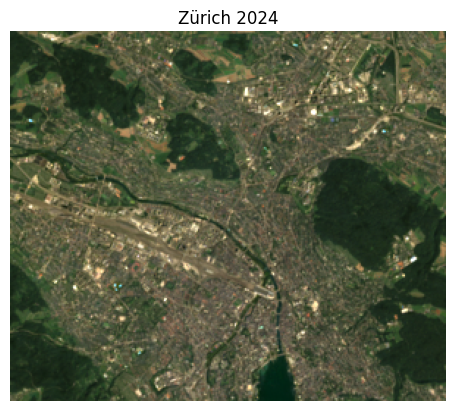

In [6]:
#reference Picture

def normalize(array, vmin=0, vmax=0.2):
    """Normalize and clip array to a specific range (default 0 to 0.4)"""
    # Clip the array to the specified vmin and vmax
    clipped = np.clip(array, vmin, vmax)
    # Scale the clipped array to 0-1 for display
    return (clipped - vmin) / (vmax - vmin)

with xr.open_dataset("../data/raw/LandsatComposite_Zurich_2024.tif", engine = "rasterio") as src:
            Blue_ref = normalize(src.sel(band = 1).band_data)
            Green_ref = normalize(src.sel(band = 2).band_data)
            Red_ref = normalize(src.sel(band=3).band_data)

rgb = np.dstack((Red_ref, Green_ref, Blue_ref))

fig, ax = plt.subplots()

ax.imshow(rgb)
ax.set_title("Zürich 2024")
ax.set_axis_off()

# 2. How did LST and NDVI change from 1985 to 2024?
## 2.1 Simple Visualization of change
This code produces interactive hvplot animations of LST and NDVI at the different years

In [62]:
#calculate raw NDVI
NDVI = (NIR - Red)/(NIR + Red)

# produce thresholded layer
threshold = 0.3 # standart for mixed vegetation
NDVI_filtered = NDVI.where(NDVI >= threshold)

In [8]:
def limits(array, p = 2):
    vmin = np.percentile(array, p)
    vmax = np.percentile(array, 100-p)
    return vmin, vmax
    

#plot LST
LST_min_hv, LST_max_hv = limits(LST)

LST_hvplot = LST.hvplot(x = "x", y = "y", groupby = "time", cmap = cmc.lajolla_r,
              clim = (LST_min_hv, LST_max_hv),
              clabel = "Land Surface Temperature [°C]", 
              aspect='equal', 
              xaxis = None, yaxis = None)


NDVI_filtered = NDVI.where(NDVI >= threshold)
#plot NDVI
NDVI_min_hv, NDVI_max_hv = limits(NDVI_filtered) 
#NDVI_max_hv=np.percentile(NDVI, 98)               #only max used -->almost no negative values
NDVI_hvplot = NDVI_filtered.hvplot(x = "x", y = "y", groupby = "time", cmap = "YlGn",
              clim = (threshold, 1),# 1 = normal upper limit of NDVI
              clabel = "NDVI", 
              aspect='equal',
              shared_axes = False, 
              xaxis = None, yaxis = None,
              bgcolor="lightgray")


LST_hvplot + NDVI_hvplot

BokehModel(combine_events=True, render_bundle={'docs_json': {'ca5b7add-4171-4529-abb3-652c193549ce': {'version…

## 2.2 NDVI change in reference to 1985
This code calculates the difference of each layer to the reference year creates an animation through time


In [9]:
#calculate difference 
NDVI_dif = NDVI.sel(time = slice(1988,2024)) - NDVI.sel(time = 1985)

#set boundaries for visualisation centerd around 0
NDVI_min, NDVI_max = limits(NDVI_dif)
NDVI_boundry = max(abs(NDVI_min), abs(NDVI_max))# center around 0

#animate NDVI
NDVI_dif.hvplot(x = "x", y = "y", groupby = "time", cmap = cmc.bam,
              clim = (-NDVI_boundry, NDVI_boundry),
              clabel = "Change in NDVI in reference to 1985", 
              aspect='equal', 
              xaxis = None, yaxis = None,
              widget_location = "bottom",
              widget_type = "scrubber")

BokehModel(combine_events=True, render_bundle={'docs_json': {'a643d378-483b-4d9d-af17-e79da411c9c5': {'version…

##  2.3 Modelling change in Collapsed space
In this Segment, the spatial extent of the data is collapsed into means, resulting in one overall value per 3-annual period. To these values, a linear model is fitted to measure the rate of change.

Text(0.5, 0, 'year')

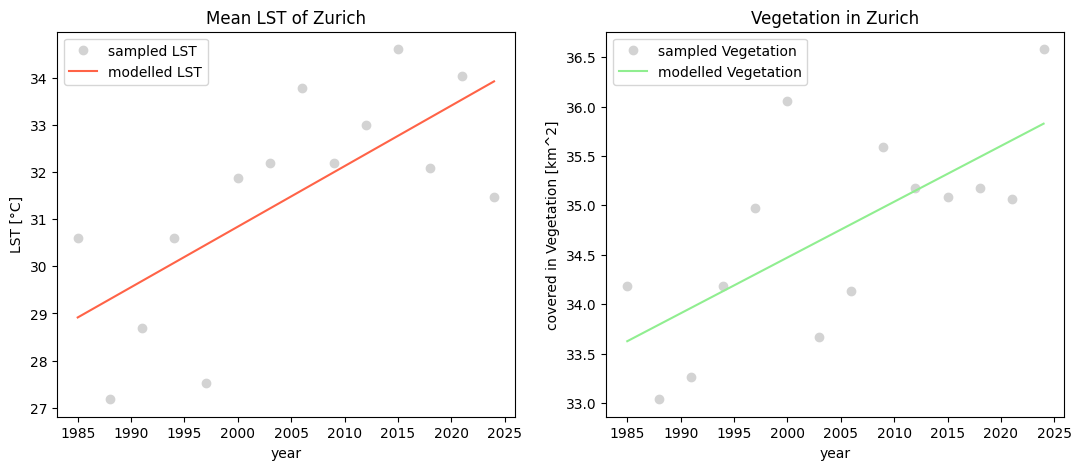

In [63]:
# change in overall NDVI aber summe aller pixel
pixelsize = NDVI.rio.resolution()
NDVI_sum = NDVI_filtered.sum(dim =["x","y"])*(0.03**2)## to get km^2 instead of pixels

NDVI_sum_fit = NDVI_sum.polyfit(dim = "time", deg = 1)
NDVI_sum_trend_line = xr.polyval(NDVI_sum.time, NDVI_sum_fit.polyfit_coefficients)

# change in overall LST
LST_mean = LST.mean(dim =["x","y"])
LST_mean_fit = LST_mean.polyfit(dim = "time", deg = 1)
LST_mean_trend_line = xr.polyval(LST_mean.time, LST_mean_fit.polyfit_coefficients)

#plotting
fig, ax = plt.subplots(1,2, figsize = (13,5))

LST_mean.plot(ax = ax[0],marker = "o", ls= "", label = "sampled LST", color = "lightgrey")
LST_mean_trend_line.plot(ax = ax[0], label = "modelled LST", color = "tomato")
ax[0].set_title("Mean LST of Zurich")
ax[0].legend()
ax[0].set_ylabel("LST [°C]")
ax[0].set_xlabel("year")

NDVI_sum.plot(ax = ax[1], marker = "o", ls = "", label = "sampled Vegetation", color = "lightgrey")
NDVI_sum_trend_line.plot(ax= ax[1], label = "modelled Vegetation", color = "lightgreen")
ax[1].set_title("Vegetation in Zurich")
ax[1].legend()
ax[1].set_ylabel("covered in Vegetation [km^2]")
ax[1].set_xlabel("year")

Text(0.5, 0, 'year')

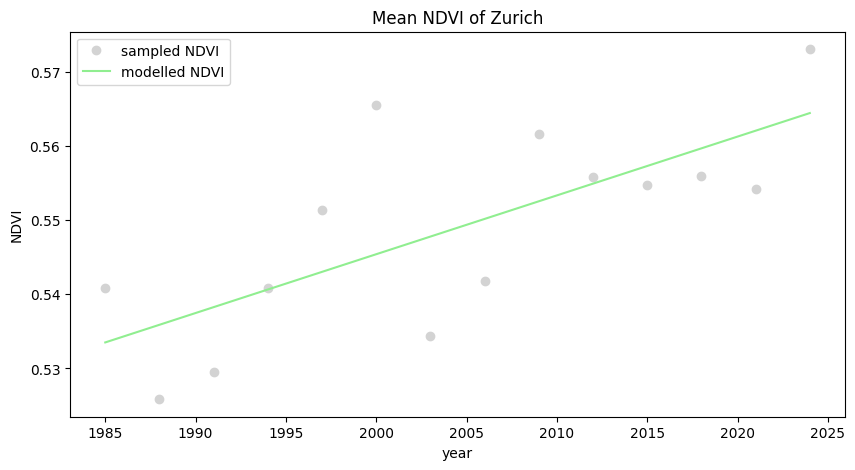

In [66]:
# change in overall NDVI


NDVI_mean = NDVI.mean(dim =["x","y"])

NDVI_mean_fit = NDVI_mean.polyfit(dim = "time", deg = 1)
NDVI_mean_trend_line = xr.polyval(NDVI_mean.time, NDVI_mean_fit.polyfit_coefficients)

#plotting
fig, ax = plt.subplots(figsize = (10,5))


NDVI_mean.plot(ax = ax, marker = "o", ls = "", label = "sampled NDVI", color = "lightgrey")
NDVI_mean_trend_line.plot(ax= ax, label = "modelled NDVI", color = "lightgreen")
ax.set_title("Mean NDVI of Zurich")
ax.legend()
ax.set_ylabel("NDVI")
ax.set_xlabel("year")

#### NDVI explanation:
wahrscheinlich nicht siginfikant (ein Punkt im Wald ähnliche SChwankungen (siehe unten))--> evtl auch aufgrund unterschiedlichen Satelitten

### Refrencing a single Pixel  for visual assessment of significance of NDVI

Text(0.5, 0, 'year')

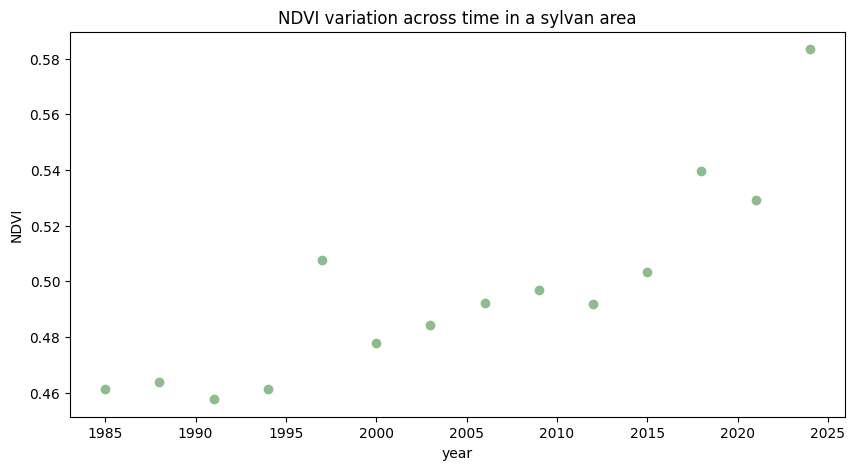

In [68]:
coordinates = (2683638.80, 1246727.00)# coordinates in LV95, place in forest on Züriberg

point_NDVI = NDVI.sel(x= coordinates[1], y = coordinates[0], method = "nearest")
point_LST = LST.sel(x= coordinates[1], y = coordinates[0], method = "nearest")

fig, ax = plt.subplots(figsize=(10,5))

point_NDVI.plot(ax = ax, color = "darkseagreen", marker = "o", lw = 0)## = Background change between years
ax.set_title("NDVI variation across time in a sylvan area")
ax.set_ylabel("NDVI")
ax.set_xlabel("year")

## 2.4 Modelling Change pixelwise
Here, similarly to 2.3, the rate of change is measured using a linear regression, but this time a regrssion is fitted for every pixel seperatly.

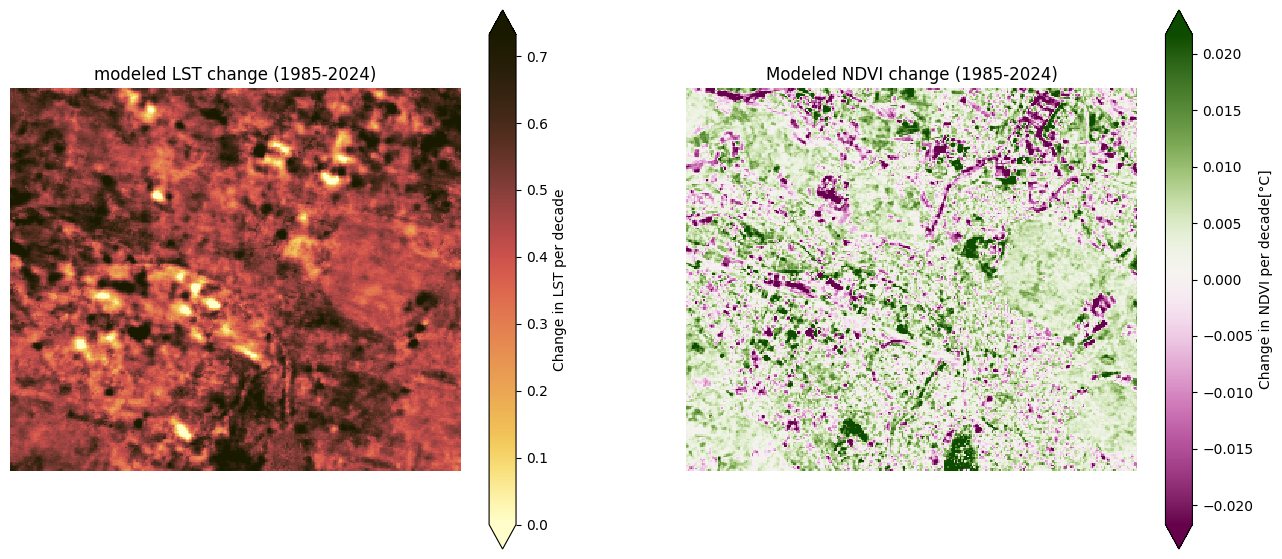

In [13]:

NDVI_fit = NDVI.polyfit(dim = "time", deg = 1)
NDVI_slope10 = NDVI_fit.polyfit_coefficients.sel(degree = 1)/3*10

# change in overall LST
LST_fit = LST.polyfit(dim = "time", deg = 1)
LST_slope10 = LST_fit.polyfit_coefficients.sel(degree = 1)/3*10 # slope is in 3 year increments (int not dateTime!)

#plotting
fig, ax = plt.subplots(1,2, figsize = (16,7))

# plot slope of LST
LST_slope_min, LST_slope_max = limits(LST_slope10)
LST_slope_boundry = max(abs(LST_slope_min), abs(LST_slope_max))

LST_slope10.plot(ax=ax[0], 
                 vmin = 0 ,
                 vmax = LST_slope_boundry, 
                 cmap = cmc.lajolla_r,
                 cbar_kwargs = {"label" : "Change in LST per decade"})
ax[0].set_axis_off()
ax[0].set_title("modeled LST change (1985-2024)")
ax[0].set_aspect('equal')

#plot slope of NDVI
NDVI_slope_min, NDVI_slope_max = limits(NDVI_slope10)
NDVI__slope_boundry = max(abs(NDVI_slope_min), abs(NDVI_slope_max))

NDVI_slope10.plot(ax= ax[1], 
                  vmin = - NDVI__slope_boundry, 
                  vmax = NDVI__slope_boundry, 
                  cmap = cmc.bam, 
                  cbar_kwargs = {"label" : "Change in NDVI per decade[°C]"})
ax[1].set_axis_off()
ax[1].set_title("Modeled NDVI change (1985-2024)")
ax[1].set_aspect('equal')

# 3. How do NDVI und LST correlate?
## 3.1 Analysis of one year
Here, we fit a linear regression with land Surface Temperature as the response and NDVI as the explaner variable. To better see the relation between the 2 variables, we only look at one year, otherwise the effect of climate change masks the patterns.

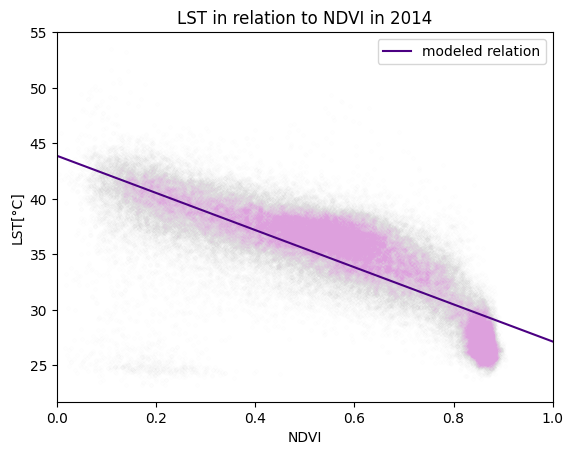

In [ ]:
#extract 2024 data
year = 2014 ## change year
NDVI_y = NDVI.sel(time = year, method = "nearest")
LST_y = LST.sel(time=year, method = "nearest")

# calculate correlation
LST_NDVI_y = np.polyfit(NDVI_y.values.flatten(), LST_y.values.flatten(), deg = 1)
intercept = LST_NDVI_y[1]
slope = LST_NDVI_y[0]

#plot LST against NDVI
fig, ax = plt.subplots()

ax.scatter(NDVI_y, LST_y, marker = ".", alpha = 0.005, c ="plum")
ax.axline((0,intercept),slope=slope, color = "indigo", label = "modeled relation")
ax.set_xlim(xmin = 0, xmax= 1)
ax.set_title(f"LST in relation to NDVI in {year}")
ax.set_xlabel("NDVI")
ax.set_ylabel("LST[°C]")
ax.legend()


kommentar: feld unten = see

Gesamte Zeit

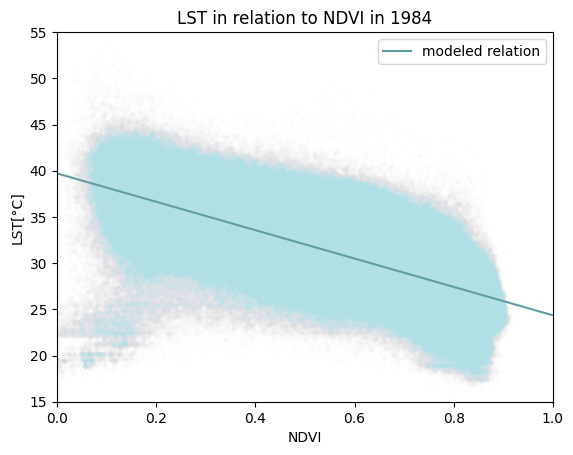

In [15]:


# calculate correlation
LST_NDVI= np.polyfit(NDVI.values.flatten(), LST.values.flatten(), deg = 1)
intercept = LST_NDVI[1]
slope = LST_NDVI[0]

#plot LST against NDVI
fig, ax = plt.subplots()
ax.plot(NDVI.values.flatten(), LST.values.flatten(),  marker = ".", ls = "", alpha = 0.002, color = "powderblue")
ax.axline((0,intercept),slope=slope, color = "cadetblue", label = "modeled relation")
ax.set_xlim(xmin = 0, xmax= 1)
ax.set_ylim(15, 55)
ax.set_title(f"LST in relation to NDVI in {year}")
ax.set_xlabel("NDVI")
ax.set_ylabel("LST[°C]")
ax.legend()




## 3.2 Does the Correlation change with the advance of climate change?

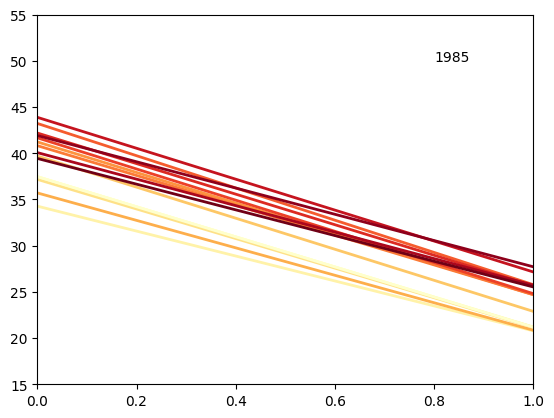

In [16]:
## animation

fig, ax = plt.subplots()
#configure ax
ax.set_xlim(xmin = 0, xmax= 1)
ax.set_ylim(15, 55)


# 1 for ervery year
colors = colors = ['#ffffcc', '#fff2a8', '#fee187', '#fdc766', '#fdae4b', '#fd943f', '#fb7a36',
                    '#f55c2e', '#ec4027', '#dc2a22', '#c5141f', '#ab071d', '#8e001b', '#700016']

#generate slope and intercept for every year
year_fits = []
for i, year in enumerate(NDVI.time.values):
    NDVI_y = NDVI.sel(time = year)
    LST_y = LST.sel(time = year)
    LST_NDVI_y= np.polyfit(NDVI_y.values.flatten(), LST_y.values.flatten(), deg = 1)
    intercept_y = LST_NDVI_y[1]
    slope_y = LST_NDVI_y[0]

    year_fits.append({"intercept": intercept_y,
                       "slope" : slope_y, 
                       "color" : colors[i], 
                       "label" : f"{year}"})

# add year of annotation
time = ax.annotate("", (0.8,50))

#define what changes in animation with each frame
def update(frame):
    #get year specific data
    fit = year_fits[frame]

    #draw line
    line = ax.axline(
        (0, fit["intercept"]),
        slope=fit["slope"],
        color=fit["color"],
        linewidth=2)
    
    
    #update year annotation
    time.set_text(fit["label"])
    return line, time

#create animation
ani = FuncAnimation(
    fig,
    update,
    frames=len(year_fits),
    interval=800)

display(HTML(ani.to_jshtml()))



/////OLD

# change in LST explained by NDVI 
lol scwirig wel LST ja aus sut sich gänderet het..

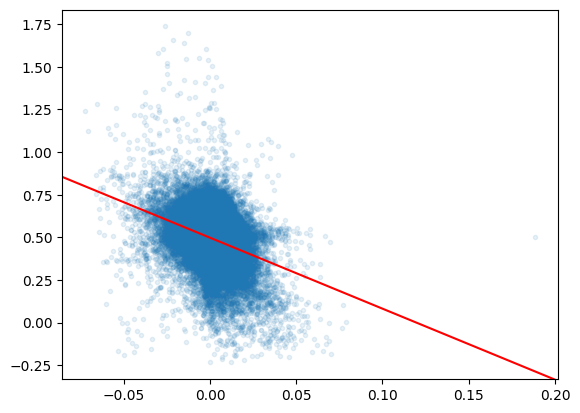

In [17]:
flat_LST_slope = LST_slope10.values.flatten()
flat_NDVI_slope = NDVI_slope10.values.flatten()

LST_NDVI = np.polyfit(flat_NDVI_slope,flat_LST_slope, deg = 1)

intercept = LST_NDVI[1]
slope = LST_NDVI[0]

fig, ax = plt.subplots()
ax.plot(flat_NDVI_slope, flat_LST_slope, marker = ".", ls = "", alpha = 0.1)
ax.axline((0,intercept),slope=slope, color = "red")


Wahrscheinlich zu abstrakt, grösster teil der LSt_change explained durch climate change

?? simple cahngmap in lST

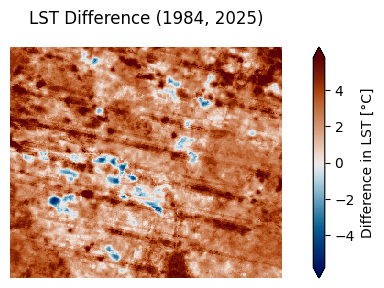

In [18]:
# extract year values from data Cube
LST_2024 = LST.sel(time = 2024)
LST_1985 = LST.sel(time = 1985)

dif_LST = LST_2024 - LST_1985 ## halt tagesabhängig, noch überlegen ob das sinn macht

fig , ax = plt.subplots(figsize = (8,3))

#determine vmin/max LST
LST_min = np.percentile(dif_LST, 2)# percentile to crop outliers
LST_max = np.percentile(dif_LST.values, 98)
LST_bound = max(abs(LST_min), abs(LST_max))# center around 0
#plot LST
dif_LST.plot(ax=ax,
            vmin = - LST_bound, 
            vmax = LST_bound,
            cmap = cmc.vik,
              cbar_kwargs = {"label": "Difference in LST [°C]"}) ##band in Kelvin
ax.set_axis_off()
ax.set_title("LST Difference (1984, 2025)")
ax.set_aspect('equal')


## note: for reference: add lables, context etc. lake etc...> mask for lake

(15.0, 55.0)

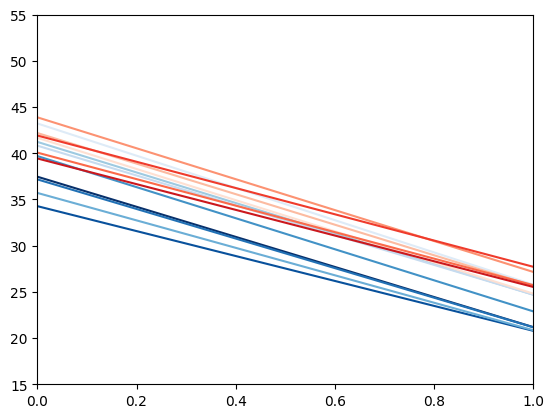

In [19]:


#plot LST against NDVI
fig, ax = plt.subplots()

ax.axline((0,intercept),slope=slope, color = "black", label = "general trend", linewidth = 2)

## plot years seperatly!--> put a legend on them
colors = ("#08306b", "#08519c", "#2171b5", "#4292c6", "#6baed6", "#9ecae1", "#c6dbef", "#deebf7", 
          "#fee0d2", "#fcbba1", "#fc9272", "#fb6a4a", "#ef3b2c", "#cb181d")
i = 0
for year in NDVI.time.values:
    NDVI_y = NDVI.sel(time = year)
    LST_y = LST.sel(time = year)
    LST_NDVI_y= np.polyfit(NDVI_y.values.flatten(), LST_y.values.flatten(), deg = 1)
    intercept_y = LST_NDVI_y[1]
    slope_y = LST_NDVI_y[0]

    ax.axline((0,intercept_y),slope=slope_y, color = colors[i], label = "general trend")
    #ax.plot(NDVI_y.values.flatten(), LST_y.values.flatten(),  marker=".", ls = "",alpha = 0.01, color = colors[i])
    i +=1
ax.set_xlim(xmin = 0, xmax= 1)
ax.set_ylim(15, 55)



In [20]:
rows = []

for year in NDVI.time.values:

    ndvi_vals = NDVI.sel(time=year).values.flatten()
    lst_vals = LST.sel(time=year).values.flatten()

    for ndvi, lst in zip(ndvi_vals, lst_vals):
        rows.append({
            "NDVI": ndvi,
            "LST": lst,
            "year": year
        })

NDVI_LST = pd.DataFrame(rows)

NDVI_LST.to_csv("../data/processed/NDVI_LST.csv", index = False)## make ordner reproducable
NDVI_LST

,NDVI,LST,year
0,0.792822,23.877610,1985
1,0.802852,24.221121,1985
2,0.835381,24.523616,1985
3,0.826407,24.561214,1985
4,0.749989,25.104679,1985
...,...,...,...
1047811,0.286695,32.359427,2024
1047812,0.373403,31.894576,2024
1047813,0.537959,31.448524,2024
1047814,0.511917,31.291296,2024
